# Animal Image Classification with Transfer Learning
### Cats vs Dogs vs Snakes

We have about 3,000 photos of cats, dogs and snakes. We want a model that looks at a photo
and says which of the three animals it is.

Instead of building a network from zero, we take a network that was already trained on
millions of photos (**ResNet18**, trained on ImageNet) and teach it our 3 classes.
This idea is called **transfer learning**.

**Plan:**
1. Load the dataset from Hugging Face.
2. Split it into train / validation / test.
3. Load a pretrained ResNet18 and replace its last layer.
4. Train in two steps: first only the new layer, then also the last block of the network.
5. Check the result with a confusion matrix and look at the mistakes.

**Dataset:** `AlvaroVasquezAI/Animal_Image_Classification_Dataset` on Hugging Face.
Run this on Google Colab (a GPU runtime is faster, but CPU also works).

## Why transfer learning?

- An image model first has to learn basic things: edges, colors, textures, simple shapes.
  Learning these from zero needs a very large number of images.
- ResNet18 was already trained on 1.2 million images, so it already knows these basic things.
- We only have ~3,000 images. That is enough to teach it "cat vs dog vs snake",
  but not enough to teach it everything from scratch.
- So we keep the part that already understands shapes and textures, and only train the
  final decision part.

```
Early layers  -> general (edges, color, texture)  -> keep frozen
Later layers  -> more specific                    -> train gently
Final layer   -> built for the old 1000 classes   -> replace completely
```

## 1. Install and check the setup

Colab already has PyTorch, torchvision and `huggingface_hub`. We only add scikit-learn
for the metrics.

In [1]:
# Install the library Colab does not include by default
!pip install -q scikit-learn

import torch, torchvision
print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)
print("GPU available:", torch.cuda.is_available())
# If this prints False and you want a GPU:
#   menu  Runtime > Change runtime type > GPU
# The notebook still runs on CPU, just slower.

torch: 2.11.0+cpu
torchvision: 0.26.0+cpu
GPU available: False


In [2]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# Fix the random seed so every run gives the same split and similar results.
# This lets us compare "before" and "after" fairly.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cpu


## 2. Download the dataset

This dataset is a single zip file with three folders: `cats/`, `dogs/`, `snakes/`
(1,000 images each). We download it from the Hugging Face Hub, unzip it, and collect
the image file paths grouped by folder name.

In [3]:
import os
import zipfile
from huggingface_hub import hf_hub_download

# Download the dataset zip (about 40 MB). The first run downloads it, later runs use the cache.
zip_path = hf_hub_download(
    repo_id="AlvaroVasquezAI/Animal_Image_Classification_Dataset",
    filename="cats_dogs_snakes.zip",
    repo_type="dataset",
)

EXTRACT_DIR = "/content/animal_data"
with zipfile.ZipFile(zip_path) as z:
    z.extractall(EXTRACT_DIR)

# Walk the extracted files and group image paths by the name of the folder they are in.
label_names = ["cats", "dogs", "snakes"]
paths_by_class = {name: [] for name in label_names}
for root, _, files in os.walk(EXTRACT_DIR):
    folder = os.path.basename(root).lower()
    if folder in paths_by_class:
        for f in files:
            if f.lower().endswith((".jpg", ".jpeg", ".png")):
                paths_by_class[folder].append(os.path.join(root, f))

for name in label_names:
    print(f"{name:8s}: {len(paths_by_class[name])} images")

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:121: UserWarning: 
Access to the secret `HF_TOKEN` has not been granted on this notebook.
You will not be requested again.
Please restart the session if you want to be prompted again.
  warnings.warn(


cats_dogs_snakes.zip: reconstructing file:   0%|          |  0.00B / 40.1MB            

cats_dogs_snakes.zip: downloading bytes:           |  0.00B            

cats    : 1000 images
dogs    : 1000 images
snakes  : 1000 images


## 3. Split into train / validation / test

We need three separate sets:
- **train** – the model learns from these
- **validation** – we use these to make choices (settings, when to stop)
- **test** – we look at these only once, at the very end, for an honest score

We use a 70 / 15 / 15 split. "Stratified" means each split keeps the same class
balance as the full dataset.

In [4]:
from PIL import Image
from sklearn.model_selection import train_test_split


class ImageList:
    """A simple list of images. ImageList[i] -> {"image": PIL image, "label": int}."""

    def __init__(self, paths, labels):
        self.paths = paths
        self.labels = labels

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        # open inside a "with" so the file is closed right away (some images are not RGB)
        with Image.open(self.paths[idx]) as img:
            return {"image": img.convert("RGB"), "label": self.labels[idx]}


# One flat list of (image_path, label_id), where label_id is the index into label_names.
all_paths, all_labels = [], []
for label_id, name in enumerate(label_names):
    for p in paths_by_class[name]:
        all_paths.append(p)
        all_labels.append(label_id)

# First cut: 70% train, 30% "rest". Then split the rest into half val, half test.
# stratify=... keeps the same share of cats / dogs / snakes in every split,
# so a low test score means "the model is weak", not "the split was unlucky".
train_p, rest_p, train_y, rest_y = train_test_split(
    all_paths, all_labels, test_size=0.30, random_state=SEED, stratify=all_labels)
val_p, test_p, val_y, test_y = train_test_split(
    rest_p, rest_y, test_size=0.50, random_state=SEED, stratify=rest_y)

train_ds = ImageList(train_p, train_y)
val_ds   = ImageList(val_p, val_y)
test_ds  = ImageList(test_p, test_y)

print("classes:", label_names)
print("train / val / test sizes:", len(train_ds), len(val_ds), len(test_ds))

classes: ['cats', 'dogs', 'snakes']
train / val / test sizes: 2100 450 450


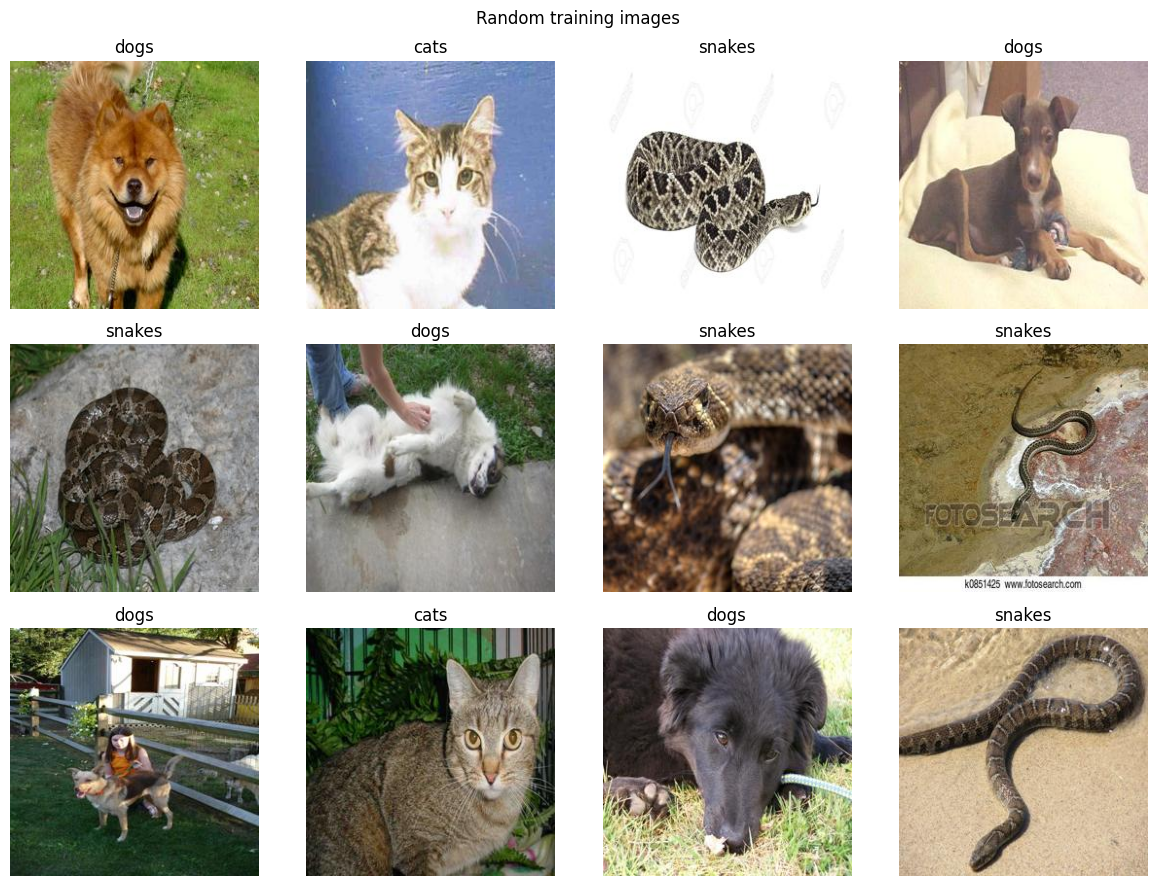

cats    : 700 images
dogs    : 700 images
snakes  : 700 images


In [5]:
# Look at the data: show 12 random training images with their labels.
# This catches wrong labels and broken images early.
fig, axes = plt.subplots(3, 4, figsize=(12, 9))
idxs = random.sample(range(len(train_ds)), 12)
for ax, i in zip(axes.flat, idxs):
    ex = train_ds[i]
    ax.imshow(ex["image"])
    ax.set_title(label_names[ex["label"]])
    ax.axis("off")
plt.suptitle("Random training images")
plt.tight_layout()
plt.show()

# Count how many images each class has.
counts = np.bincount([train_ds[i]["label"] for i in range(len(train_ds))])
for name, c in zip(label_names, counts):
    print(f"{name:8s}: {c} images")
# The classes are close to balanced, so plain accuracy is a fair metric
# and plain CrossEntropyLoss (no class weights) is fine.

## 4. Prepare the images (preprocessing and augmentation)

Every image is changed a little before the model sees it:

- **Resize to 224x224** – the size ResNet18 was trained on.
- **Normalize** with ImageNet's mean and standard deviation. The pretrained weights
  expect images scaled this exact way, so we use ImageNet's numbers, not our own dataset's.
- **Augmentation (training images only)** – small random flips, rotations and color
  changes. This gives the model more variety without changing the label
  (a flipped cat is still a cat). We do **not** do this on validation or test,
  because those must show real, unaltered performance.

In [6]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
IMG_SIZE = 224

# Training images: resize + light random changes + normalize
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Validation and test images: resize + normalize only (no random changes)
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


class AnimalDataset(Dataset):
    """Applies the transform to each image so PyTorch's DataLoader can use it.
    It returns (image_tensor, label) for each index."""

    def __init__(self, image_list, transform):
        self.ds = image_list
        self.transform = transform

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        ex = self.ds[idx]
        return self.transform(ex["image"]), ex["label"]


train_dataset = AnimalDataset(train_ds, train_transform)
val_dataset   = AnimalDataset(val_ds, eval_transform)
test_dataset  = AnimalDataset(test_ds, eval_transform)

# batch_size = 32: fits easily in memory and gives stable training.
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"train batches: {len(train_loader)} | val batches: {len(val_loader)} | test batches: {len(test_loader)}")

train batches: 66 | val batches: 15 | test batches: 15


## 5. About ResNet18

Rough shape of the network:

```
INPUT 224 x 224 x 3
  -> STEM       (first conv + pooling)
  -> LAYER1     (64 channels)
  -> LAYER2     (128 channels)
  -> LAYER3     (256 channels)
  -> LAYER4     (512 channels)      <- last block, most task-specific
  -> GLOBAL AVERAGE POOL -> 512 numbers
  -> FC (final layer): 512 -> 1000 for ImageNet   /   512 -> 3 for us
```

In the code, `layer1 ... layer4` are those four blocks and `fc` is the final layer we replace.

We pick ResNet18 (not a bigger model) because:
- Our dataset is small (~2,100 training images) and the task is easy (3 very different animals).
- A bigger model has more room to memorize the training set and overfit.
- ResNet18 trains fast, so we can try ideas quickly.

## 6. Build the model

Steps:
1. Load ResNet18 with ImageNet weights.
2. Freeze every layer (`requires_grad = False`) so training does not change them.
3. Replace the final `fc` layer with a new one that has 3 outputs. The new layer is trainable by default.

**Why freeze first:** the new layer starts with random weights, so its first updates are
large and noisy. If that noise flows into the whole network, it can damage the good
pretrained features. So we train only the new layer first, against a network that stays still.

In [7]:
NUM_CLASSES = len(label_names)  # 3: cat, dog, snake

def build_model(num_classes=NUM_CLASSES):
    # Load ResNet18 with weights learned on ImageNet.
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    # Freeze all existing layers: keep these features exactly as they are.
    for param in model.parameters():
        param.requires_grad = False

    # Replace the final layer with a fresh one for our 3 classes.
    # Read in_features from the old layer instead of hardcoding 512.
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)  # new layer is trainable by default

    return model


model = build_model().to(DEVICE)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"trainable params: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)")
# Only the new final layer is trainable now - a tiny part of the whole network.

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 181MB/s]


trainable params: 1,539 / 11,178,051 (0.01%)


## 7. Training in two phases

**Phase 1** – train only the new final layer. The rest is frozen, so we can use a normal
learning rate (`1e-3`) and a few epochs (5).

**Phase 2** – also unfreeze `layer4` (the last block) and train again with a smaller
learning rate (`1e-4`) for fewer epochs (3). The smaller rate matters: `layer4` already
holds useful knowledge, so we want small careful changes, not big ones.

Rule of thumb: **the more useful a weight already is, the smaller the learning rate it should get.**

In [8]:
def run_epoch(model, loader, criterion, optimizer=None):
    """One pass over the data. If optimizer is given -> training, otherwise -> evaluation."""
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss, correct, n = 0.0, 0, 0
    torch.set_grad_enabled(is_train)
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        if is_train:
            optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        if is_train:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        n += images.size(0)
    torch.set_grad_enabled(True)

    return total_loss / n, correct / n


def fit(model, train_loader, val_loader, epochs, lr, params=None, phase_name="phase"):
    """Train for a number of epochs, printing train/val loss and accuracy each epoch."""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(params if params is not None else model.parameters(), lr=lr)

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer)
        va_loss, va_acc = run_epoch(model, val_loader, criterion, optimizer=None)
        history["train_loss"].append(tr_loss); history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss);   history["val_acc"].append(va_acc)
        print(f"[{phase_name}] epoch {epoch}/{epochs} | "
              f"train loss {tr_loss:.4f} acc {tr_acc:.4f} | "
              f"val loss {va_loss:.4f} acc {va_acc:.4f}")
    return history


# Phase 1: train only the new final layer.
history_head = fit(model, train_loader, val_loader, epochs=5, lr=1e-3, phase_name="head-only")
# Validation accuracy is often already 85-95% after this phase alone,
# which shows how useful the pretrained features are.

[head-only] epoch 1/5 | train loss 0.4025 acc 0.8662 | val loss 0.1383 acc 0.9667
[head-only] epoch 2/5 | train loss 0.1454 acc 0.9610 | val loss 0.0996 acc 0.9667
[head-only] epoch 3/5 | train loss 0.1254 acc 0.9586 | val loss 0.0827 acc 0.9667
[head-only] epoch 4/5 | train loss 0.0979 acc 0.9719 | val loss 0.0764 acc 0.9711
[head-only] epoch 5/5 | train loss 0.0969 acc 0.9690 | val loss 0.0701 acc 0.9733


## 8. Phase 2: fine-tune the last block

Now unfreeze `layer4` and train again with a smaller learning rate.

We only unfreeze the last block because:
- Early layers learn very general things (edges, colors) that are already fine.
- `layer4` learns more specific things that can benefit from adjusting to our animals.

In [9]:
# Unfreeze layer4. The final layer is already trainable from phase 1.
for param in model.layer4.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"trainable params now: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)")

# Smaller learning rate (1e-4) and fewer epochs (3): gentle changes to good weights.
finetune_params = [p for p in model.parameters() if p.requires_grad]
history_finetune = fit(
    model, train_loader, val_loader,
    epochs=3, lr=1e-4, params=finetune_params, phase_name="fine-tune(layer4+fc)"
)

trainable params now: 8,395,267 / 11,178,051 (75.10%)
[fine-tune(layer4+fc)] epoch 1/3 | train loss 0.0959 acc 0.9690 | val loss 0.0654 acc 0.9800
[fine-tune(layer4+fc)] epoch 2/3 | train loss 0.0413 acc 0.9867 | val loss 0.0531 acc 0.9844
[fine-tune(layer4+fc)] epoch 3/3 | train loss 0.0288 acc 0.9914 | val loss 0.0343 acc 0.9867


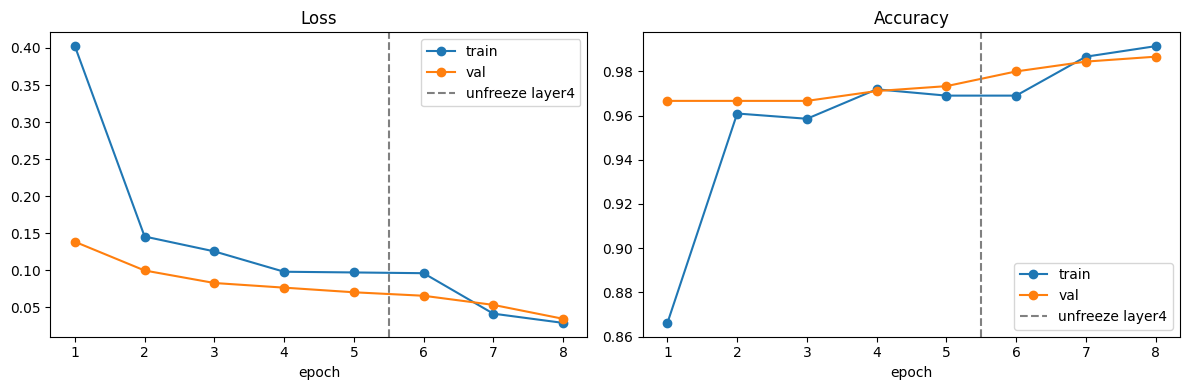

In [10]:
# Plot loss and accuracy for both phases. The dashed line marks where we unfroze layer4.
def plot_history(h1, h2, switch_epoch):
    train_loss = h1["train_loss"] + h2["train_loss"]
    val_loss   = h1["val_loss"]   + h2["val_loss"]
    train_acc  = h1["train_acc"]  + h2["train_acc"]
    val_acc    = h1["val_acc"]    + h2["val_acc"]
    epochs = range(1, len(train_loss) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, tr, va, title in [
        (axes[0], train_loss, val_loss, "Loss"),
        (axes[1], train_acc, val_acc, "Accuracy"),
    ]:
        ax.plot(epochs, tr, label="train", marker="o")
        ax.plot(epochs, va, label="val", marker="o")
        ax.axvline(switch_epoch + 0.5, color="gray", linestyle="--", label="unfreeze layer4")
        ax.set_title(title); ax.set_xlabel("epoch"); ax.legend()
    plt.tight_layout()
    plt.show()

plot_history(history_head, history_finetune, switch_epoch=len(history_head["train_loss"]))

## 9. Final test

Now we use the test set, which we have not touched until now. We report accuracy,
a per-class report (precision / recall / F1), and a confusion matrix.

TEST accuracy: 0.9889

              precision    recall  f1-score   support

        cats       0.99      0.98      0.99       150
        dogs       1.00      0.99      0.99       150
      snakes       0.97      1.00      0.99       150

    accuracy                           0.99       450
   macro avg       0.99      0.99      0.99       450
weighted avg       0.99      0.99      0.99       450



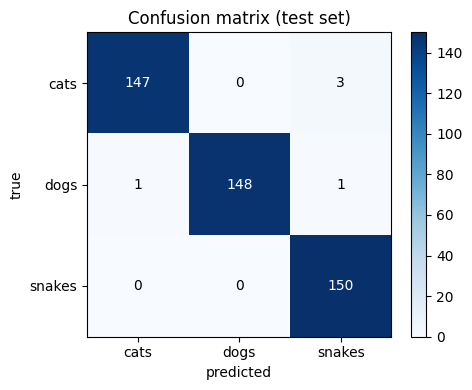

In [11]:
@torch.no_grad()
def collect_predictions(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    for images, labels in loader:
        images = images.to(DEVICE)
        preds = model(images).argmax(1).cpu()
        all_preds.append(preds)
        all_labels.append(labels)
    return torch.cat(all_preds).numpy(), torch.cat(all_labels).numpy()


test_preds, test_labels = collect_predictions(model, test_loader)
test_acc = (test_preds == test_labels).mean()
print(f"TEST accuracy: {test_acc:.4f}\n")
print(classification_report(test_labels, test_preds, target_names=label_names))

cm = confusion_matrix(test_labels, test_preds)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(label_names))); ax.set_xticklabels(label_names)
ax.set_yticks(range(len(label_names))); ax.set_yticklabels(label_names)
ax.set_xlabel("predicted"); ax.set_ylabel("true"); ax.set_title("Confusion matrix (test set)")
for i in range(len(label_names)):
    for j in range(len(label_names)):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black")
plt.colorbar(im)
plt.tight_layout()
plt.show()
# In the confusion matrix, the diagonal is correct predictions and off-diagonal cells are mistakes.
# Cat vs dog mix-ups are more expected than a snake mixed up with a mammal.

5 / 450 test images predicted wrong


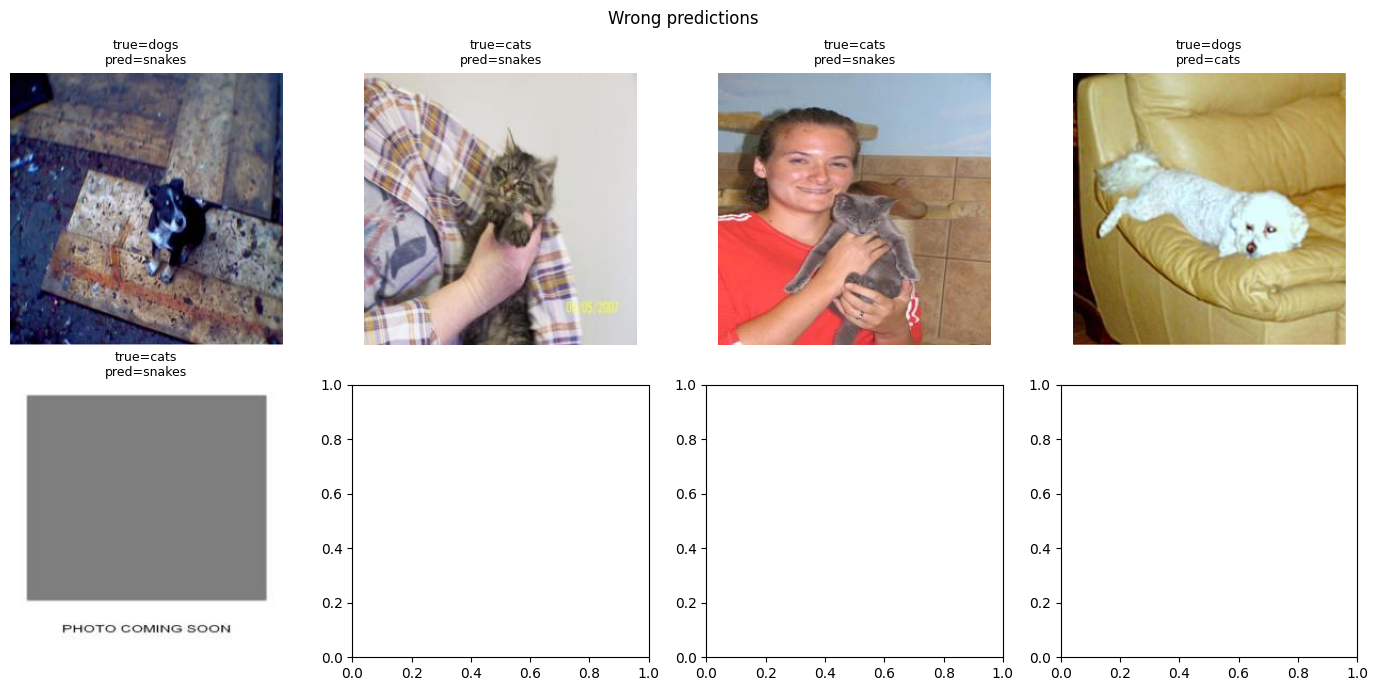

In [12]:
# Look at the actual wrong predictions.
# The numbers tell you HOW MANY mistakes; the images tell you WHY
# (hard photo? wrong label in the data? a repeating pattern?).
wrong_idx = np.where(test_preds != test_labels)[0]
print(f"{len(wrong_idx)} / {len(test_labels)} test images predicted wrong")

show = wrong_idx[:8]
if len(show):
    fig, axes = plt.subplots(2, 4, figsize=(14, 7))
    for ax, i in zip(axes.flat, show):
        img = test_ds[int(i)]["image"]
        ax.imshow(img)
        ax.set_title(f"true={label_names[test_labels[i]]}\npred={label_names[test_preds[i]]}", fontsize=9)
        ax.axis("off")
    plt.suptitle("Wrong predictions")
    plt.tight_layout()
    plt.show()

## 10. Ideas to improve

- Unfreeze `layer3` too, with an even smaller learning rate for it than for `layer4`.
- Test-time augmentation: average the prediction over the image and its flipped copy.
- Use a learning-rate schedule instead of a fixed value.
- Try ResNet34 or EfficientNet-B0 as the backbone and compare.
